In [1]:
# Import core libraries for data handling, modeling, tuning, and evaluation.
import pandas as pd
import joblib
import optuna
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt


e:\DevFiles\DevTools\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Silence non-critical warnings for cleaner notebook output.
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [3]:
# Load the cardiovascular dataset and preview shape/sample rows.
df = pd.read_csv("../data/cardiovascular.csv")
print("Shape:", df.shape)
df.head()

Shape: (5500, 17)


,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,High
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,High
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,High


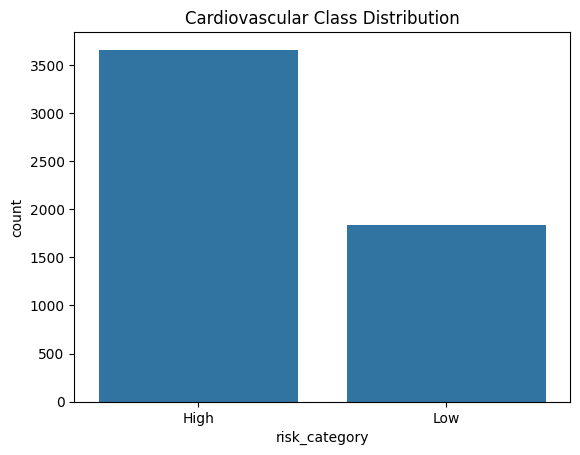

In [4]:
# Plot class distribution to check target balance visually.
plt.figure()
sns.countplot(x=df['risk_category'])
plt.title("Cardiovascular Class Distribution")
plt.show()


In [5]:
# Inspect missing values and raw target labels.
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Values:\n", df["risk_category"].unique())



Missing Values:
 Patient_ID                          0
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

Target Values:
 ['High' 'Low']


In [6]:
# Clean cardiovascular target labels and map them to strict binary classes.
df.drop(columns=["Patient_ID", "heart_disease_risk_score"], inplace=True)
df.dropna(inplace=True)
df["risk_category"] = df["risk_category"].astype(str).str.strip().str.lower()

# Strict binary mapping (dataset supports only low / high)
valid_labels = {"low", "high"}
found_labels = set(df["risk_category"].unique())
unexpected = sorted(found_labels - valid_labels)
if unexpected:
    raise ValueError(f"Unexpected target labels found: {unexpected}. Expected only {sorted(valid_labels)}")

mapping = {
    "low": 0,
    "high": 1,
}

df["risk_category"] = df["risk_category"].map(mapping).astype(int)

print("After Mapping (0=Low Risk, 1=High Risk):", df["risk_category"].value_counts())


After Mapping (0=Low Risk, 1=High Risk): risk_category
1    3662
0    1838
Name: count, dtype: int64


In [7]:
# Split cardiovascular features/target into train, validation, and test sets.
X = df.drop("risk_category", axis=1)
y = df["risk_category"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [8]:
# preprocessing pipeline (scaling + encoding) and transform feature matrices.
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

feature_names_after = numeric_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
print(f"Features after preprocessing: {len(feature_names_after)}")
print(f"Split sizes -> train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")


Numeric columns: ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'diet_quality_score', 'alcohol_units_per_week']
Categorical columns: ['smoking_status', 'family_history_heart_disease']
Features after preprocessing: 17
Split sizes -> train: (3300, 14), val: (1100, 14), test: (1100, 14)


In [9]:
# SelectKBest feature selection
print("\nFinding Best K Value...")

k_values = [5, 8, 10, 12, 15]

best_k = None
best_score = 0

for k in k_values:

    temp_selector = SelectKBest(f_classif, k=k)

    X_train_temp = temp_selector.fit_transform(X_train_prep, y_train)
    X_val_temp = temp_selector.transform(X_val_prep)

    # Apply SMOTE strictly for evaluating balanced baseline performance
    smote_temp = SMOTE(random_state=42)
    X_train_temp_sm, y_train_sm = smote_temp.fit_resample(X_train_temp, y_train)

    temp_model = RandomForestClassifier(random_state=42)
    temp_model.fit(X_train_temp_sm, y_train_sm)

    preds = temp_model.predict(X_val_temp)

    score = f1_score(y_val, preds)

    print(f"K = {k} --> F1 Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nBest K Selected: {best_k}")

selector = SelectKBest(f_classif, k=best_k)

X_train_prep = selector.fit_transform(X_train_prep, y_train)
X_val_prep = selector.transform(X_val_prep)
X_test_prep = selector.transform(X_test_prep)

selected_idx = selector.get_support(indices=True)

selected_features = [
    feature_names_after[i]
    for i in selected_idx
]

print("\nFeature Selection Complete:")
print(f"Selected {len(selected_features)} features:")
print(selected_features)



Finding Best K Value...
K = 5 --> F1 Score = 0.9174
K = 8 --> F1 Score = 0.9237
K = 10 --> F1 Score = 0.9235
K = 12 --> F1 Score = 0.9379
K = 15 --> F1 Score = 0.9552

Best K Selected: 15

Feature Selection Complete:
Selected 15 features:
['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'diet_quality_score', 'alcohol_units_per_week', 'smoking_status_Current', 'smoking_status_Never', 'family_history_heart_disease_No', 'family_history_heart_disease_Yes']


In [10]:
# Apply SMOTE on training data to reduce class imbalance.
smote = SMOTE(random_state=42)
X_train_prep, y_train = smote.fit_resample(X_train_prep, y_train)
print("SMOTE applied - training data balanced")


SMOTE applied - training data balanced


In [11]:
# Train baseline models and compare validation performance.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    "SVM": SVC(probability=True, random_state=42)
}

baseline_results = []
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    y_val_pred = model.predict(X_val_prep)

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
    })

baseline_results_df = pd.DataFrame(baseline_results)[["Model", "Accuracy", "Precision", "Recall", "F1"]]
print("\n-- Baseline Model Comparison (Validation) --")
display(baseline_results_df.sort_values("F1", ascending=False).reset_index(drop=True))



-- Baseline Model Comparison (Validation) --


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.970909,0.982118,0.974079,0.978082
1,SVM,0.960000,0.980474,0.959072,0.969655
2,XGBoost,0.951818,0.965753,0.961801,0.963773
3,Random Forest,0.940000,0.951286,0.959072,0.955163


In [12]:
# Configure cross-validation and define a helper for consistent CV reporting.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def print_cv_summary(model_name, cv_scores):
    fold_scores = [round(float(s), 4) for s in cv_scores]
    mean_f1 = float(cv_scores.mean())
    std_f1 = float(cv_scores.std())
    print(f"{model_name} CV fold F1:", fold_scores)
    return mean_f1, std_f1


In [13]:
# Run Optuna hyperparameter tuning in a simple single-loop workflow.
optuna.logging.set_verbosity(optuna.logging.WARNING)

model_tuning_plan = {
    "Logistic Regression": {"n_trials": 20},
    "Random Forest": {"n_trials": 20},
    "XGBoost": {"n_trials": 25},
    "SVM": {"n_trials": 25},
}

optimized_models = {}
cv_scores_all = {}
best_params_all = {}


def make_objective(model_name, X_train, y_train, cv):
    def objective(trial):
        if model_name == "Logistic Regression":
            params = {
                "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
                "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs", "saga"]),
                "max_iter": 1000,
                "random_state": 42,
            }
            model = LogisticRegression(**params)
        elif model_name == "Random Forest":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 600),
                "max_depth": trial.suggest_int("max_depth", 3, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "random_state": 42,
                "n_jobs": -1,
            }
            model = RandomForestClassifier(**params)
        elif model_name == "XGBoost":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 800),
                "max_depth": trial.suggest_int("max_depth", 2, 12),
                "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "random_state": 42,
                "eval_metric": "logloss",
                "n_jobs": -1,
            }
            model = XGBClassifier(**params)
        else:  # SVM
            kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
            params = {
                "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
                "kernel": kernel,
                "probability": True,
                "random_state": 42,
            }
            if kernel == "rbf":
                params["gamma"] = trial.suggest_float("gamma", 1e-4, 1e0, log=True)
            model = SVC(**params)

        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
        return float(scores.mean())
    return objective

for model_name, cfg in model_tuning_plan.items():
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        make_objective(model_name, X_train_prep, y_train, cv),
        n_trials=cfg["n_trials"],
    )
    best_params_all[model_name] = study.best_params

    if model_name == "Logistic Regression":
        tuned_model = LogisticRegression(**study.best_params, max_iter=1000, random_state=42)
    elif model_name == "Random Forest":
        tuned_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
    elif model_name == "XGBoost":
        tuned_model = XGBClassifier(**study.best_params, random_state=42, eval_metric="logloss", n_jobs=-1)
    else:
        tuned_model = SVC(**study.best_params, probability=True, random_state=42)

    tuned_model.fit(X_train_prep, y_train)
    optimized_models[model_name] = tuned_model

    scores = cross_val_score(tuned_model, X_train_prep, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_scores_all[model_name] = scores
    print_cv_summary(model_name, scores)

optimized_lr = optimized_models["Logistic Regression"]
optimized_rf = optimized_models["Random Forest"]
optimized_xgb = optimized_models["XGBoost"]
optimized_svm = optimized_models["SVM"]

lr_cv_scores = cv_scores_all["Logistic Regression"]
rf_cv_scores = cv_scores_all["Random Forest"]
xgb_cv_scores = cv_scores_all["XGBoost"]
svm_cv_scores = cv_scores_all["SVM"]


Logistic Regression CV fold F1: [0.9671, 0.9747, 0.9653, 0.976, 0.9648]
Random Forest CV fold F1: [0.9633, 0.9724, 0.9571, 0.9656, 0.9644]
XGBoost CV fold F1: [0.9692, 0.9771, 0.9595, 0.9713, 0.9725]
SVM CV fold F1: [0.9761, 0.9771, 0.9664, 0.9828, 0.9725]


In [14]:
default_params = {
    "Logistic Regression": {"C": 1.0, "solver": "lbfgs"},
    "Random Forest": {"n_estimators": 100, "max_depth": None, "min_samples_split": 2},
    "XGBoost": {"n_estimators": 100, "max_depth": 6, "learning_rate": 0.3, "subsample": 1.0, "colsample_bytree": 1.0},
    "SVM": {"C": 1.0, "kernel": "rbf", "gamma": "scale"},
}

print("\n--- Parameter Comparison: Default vs Optuna Tuned ---")
for model_name, best_params in best_params_all.items():
    print(f"\n{model_name}:")
    defaults = default_params[model_name]
    for param, tuned_val in best_params.items():
        default_val = defaults.get(param, "N/A")
        print(f"  {param:<20} default={default_val}  -->  tuned={tuned_val}")


--- Parameter Comparison: Default vs Optuna Tuned ---

Logistic Regression:
  C                    default=1.0  -->  tuned=5.0324298172936786
  solver               default=lbfgs  -->  tuned=liblinear

Random Forest:
  n_estimators         default=100  -->  tuned=567
  max_depth            default=None  -->  tuned=19
  min_samples_split    default=2  -->  tuned=2

XGBoost:
  n_estimators         default=100  -->  tuned=264
  max_depth            default=6  -->  tuned=4
  learning_rate        default=0.3  -->  tuned=0.12606472556629608
  subsample            default=1.0  -->  tuned=0.865362571444793
  colsample_bytree     default=1.0  -->  tuned=0.9238315673412456

SVM:
  kernel               default=rbf  -->  tuned=rbf
  C                    default=1.0  -->  tuned=9.010867245880785
  gamma                default=scale  -->  tuned=0.09275161006653856


In [15]:
# Print consolidated 5-fold CV mean +/- std for all tuned models.
cv_scores_all = {
    "Logistic Regression": lr_cv_scores,
    "Random Forest": rf_cv_scores,
    "XGBoost": xgb_cv_scores,
    "SVM": svm_cv_scores,
}

print("\n5-Fold CV Mean +/- Std (All Models):")
name_width = max(len(name) for name in cv_scores_all)
for model_name, scores in cv_scores_all.items():
    mean_f1 = float(scores.mean())
    std_f1 = float(scores.std())
    print(f"  {model_name:<{name_width}} : {mean_f1:.4f} +/- {std_f1:.4f}")



5-Fold CV Mean +/- Std (All Models):
  Logistic Regression : 0.9696 +/- 0.0048
  Random Forest       : 0.9646 +/- 0.0049
  XGBoost             : 0.9699 +/- 0.0058
  SVM                 : 0.9750 +/- 0.0054



-- Optimized Model Comparison (Validation) --


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.971818,0.982143,0.975443,0.978782
1,SVM,0.960000,0.968707,0.971351,0.970027
2,XGBoost,0.957273,0.966033,0.969986,0.968005
3,Random Forest,0.939091,0.948787,0.960437,0.954576


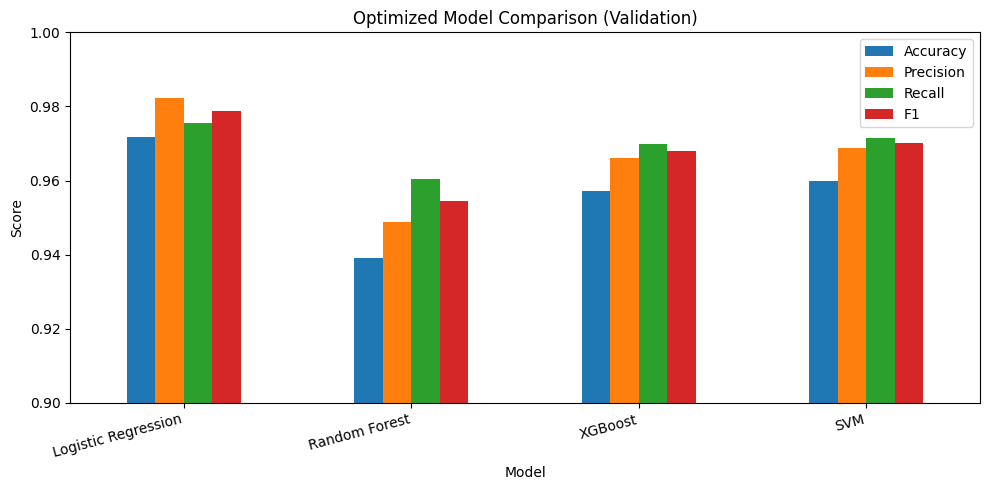

In [16]:
# Compare optimized models on validation metrics.
optimized_models = {
    "Logistic Regression": optimized_lr,
    "Random Forest": optimized_rf,
    "XGBoost": optimized_xgb,
    "SVM": optimized_svm,
}

optimized_results = []
for name, model in optimized_models.items():
    y_val_pred = model.predict(X_val_prep)

    optimized_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
    })

optimized_results_df = pd.DataFrame(optimized_results)[["Model", "Accuracy", "Precision", "Recall", "F1"]]
print("\n-- Optimized Model Comparison (Validation) --")
display(optimized_results_df.sort_values("F1", ascending=False).reset_index(drop=True))

# Plot bar chart for Optimized Model Comparison (Validation)
optimized_results_df.set_index("Model").plot(kind="bar", figsize=(10, 5))
plt.title("Optimized Model Comparison (Validation)")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.ylim(0.90, 1.0)
plt.tight_layout()
plt.show()


In [17]:
# -- Threshold Tuning --
threshold_candidates = [round(i * 0.05, 2) for i in range(6, 15)]

val_probs_lr = optimized_lr.predict_proba(X_val_prep)[:, 1]
best_threshold_lr = 0.5
best_f1_lr = f1_score(y_val, (val_probs_lr >= 0.5).astype(int))
for t in threshold_candidates:
    score = f1_score(y_val, (val_probs_lr >= t).astype(int))
    if score > best_f1_lr:
        best_f1_lr, best_threshold_lr = score, t
print(f"Logistic Regression : best threshold = {best_threshold_lr}, F1 = {best_f1_lr:.4f}")

val_probs_rf = optimized_rf.predict_proba(X_val_prep)[:, 1]
best_threshold_rf = 0.5
best_f1_rf = f1_score(y_val, (val_probs_rf >= 0.5).astype(int))
for t in threshold_candidates:
    score = f1_score(y_val, (val_probs_rf >= t).astype(int))
    if score > best_f1_rf:
        best_f1_rf, best_threshold_rf = score, t
print(f"Random Forest       : best threshold = {best_threshold_rf}, F1 = {best_f1_rf:.4f}")

val_probs_xgb = optimized_xgb.predict_proba(X_val_prep)[:, 1]
best_threshold_xgb = 0.5
best_f1_xgb = f1_score(y_val, (val_probs_xgb >= 0.5).astype(int))
for t in threshold_candidates:
    score = f1_score(y_val, (val_probs_xgb >= t).astype(int))
    if score > best_f1_xgb:
        best_f1_xgb, best_threshold_xgb = score, t
print(f"XGBoost             : best threshold = {best_threshold_xgb}, F1 = {best_f1_xgb:.4f}")

val_probs_svm = optimized_svm.predict_proba(X_val_prep)[:, 1]
best_threshold_svm = 0.5
best_f1_svm = f1_score(y_val, (val_probs_svm >= 0.5).astype(int))
for t in threshold_candidates:
    score = f1_score(y_val, (val_probs_svm >= t).astype(int))
    if score > best_f1_svm:
        best_f1_svm, best_threshold_svm = score, t
print(f"SVM                 : best threshold = {best_threshold_svm}, F1 = {best_f1_svm:.4f}")


Logistic Regression : best threshold = 0.5, F1 = 0.9788
Random Forest       : best threshold = 0.55, F1 = 0.9561
XGBoost             : best threshold = 0.55, F1 = 0.9685
SVM                 : best threshold = 0.5, F1 = 0.9687


In [18]:
# Select the best optimized model using threshold-adjusted validation F1.
tuning_results = {
    "Logistic Regression": (optimized_lr, best_threshold_lr, best_f1_lr),
    "Random Forest": (optimized_rf, best_threshold_rf, best_f1_rf),
    "XGBoost": (optimized_xgb, best_threshold_xgb, best_f1_xgb),
    "SVM": (optimized_svm, best_threshold_svm, best_f1_svm),
}

best_model_name = max(tuning_results, key=lambda k: tuning_results[k][2])
best_model, threshold, best_threshold_f1 = tuning_results[best_model_name]

print(f"Best Model : {best_model_name}")
print(f"Threshold  : {threshold}")
print(f"Val F1     : {best_threshold_f1:.4f}")


Best Model : Logistic Regression
Threshold  : 0.5
Val F1     : 0.9788



-- Final Test Performance [Logistic Regression | threshold=0.5] --
Accuracy  : 0.9636
Precision : 0.9887
Recall    : 0.9563
F1 Score  : 0.9722


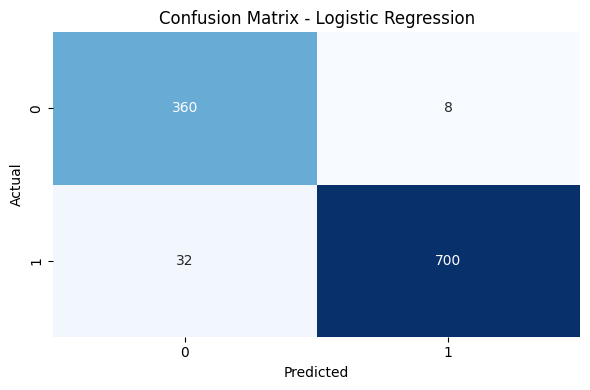

In [19]:
# Evaluate final model on test set and plot confusion matrix.
y_test_prob = best_model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= threshold).astype(int)
cm_test = confusion_matrix(y_test, y_test_pred)

print(f"\n-- Final Test Performance [{best_model_name} | threshold={threshold}] --")
print(f"Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_test_pred):.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


In [20]:
# Artifact Saving
final_artifact = {
    "model": best_model,
    "preprocessor": preprocessor,
    "selector": selector,
    "threshold": threshold,
    "selected_features": selected_features,
    "feature_columns": list(X.columns),
    "features": list(X.columns),
    "model_name": best_model_name,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "positive_class": 1,
    "negative_class": 0,
    "class_label_map": {0: "Low Risk", 1: "High Risk"},
}

joblib.dump(final_artifact, "../models/cardiovascular_model.pkl")

print("\nCardiovascular model saved successfully!")
print(f"Model: {best_model_name}")
print(f"Threshold: {threshold}")
print(f"Selector: SelectKBest(k={best_k})")
print("Preprocessor: StandardScaler + OneHotEncoder")



Cardiovascular model saved successfully!
Model: Logistic Regression
Threshold: 0.5
Selector: SelectKBest(k=15)
Preprocessor: StandardScaler + OneHotEncoder
